In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [10]:
print("--- Đang tải dữ liệu từ Hugging Face ---")
dataset = load_dataset("chillies/IELTS-writing-task-2-evaluation")

# Gộp tập train và test để thực hiện EDA tổng thể
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Tổng số mẫu dữ liệu: {len(df)}")
print(f"Các cột hiện có: {df.columns.tolist()}")

--- Đang tải dữ liệu từ Hugging Face ---
Tổng số mẫu dữ liệu: 10324
Các cột hiện có: ['prompt', 'essay', 'evaluation', 'band']


In [11]:
print("\n--- Kiểm tra dữ liệu thiếu (Missing Values) ---")
print(df.isnull().sum())

print("\n--- Kiểm tra dữ liệu trùng lặp (Duplicates) ---")
duplicate_count = df['essay'].duplicated().sum()
print(f"Số lượng Essay bị trùng: {duplicate_count}")


--- Kiểm tra dữ liệu thiếu (Missing Values) ---
prompt        0
essay         0
evaluation    0
band          0
dtype: int64

--- Kiểm tra dữ liệu trùng lặp (Duplicates) ---
Số lượng Essay bị trùng: 1339


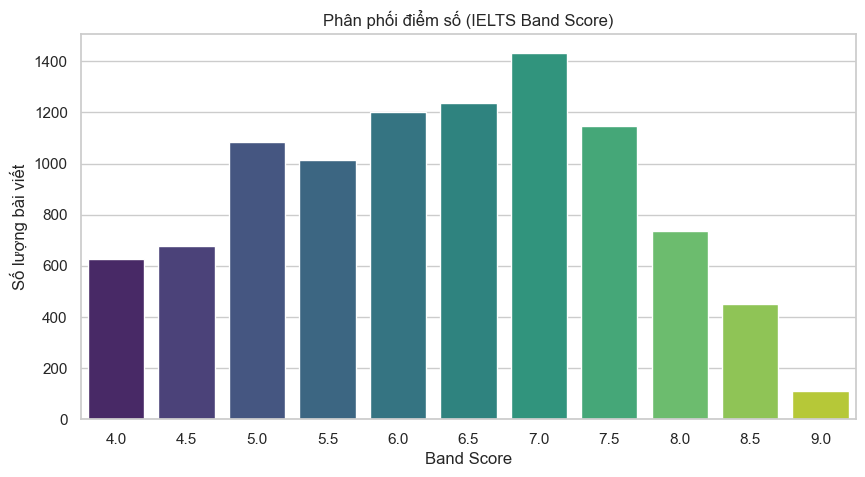


--- Thống kê mô tả điểm Band ---
count    9712.000000
mean        6.292473
std         1.267894
min         4.000000
25%         5.500000
50%         6.500000
75%         7.500000
max         9.000000
Name: band, dtype: float64


In [12]:
# Chuyển đổi cột 'band' sang kiểu số để tính toán
df['band'] = pd.to_numeric(df['band'], errors='coerce')

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='band', palette='viridis')
plt.title('Phân phối điểm số (IELTS Band Score)')
plt.xlabel('Band Score')
plt.ylabel('Số lượng bài viết')
plt.show()

print("\n--- Thống kê mô tả điểm Band ---")
print(df['band'].describe())

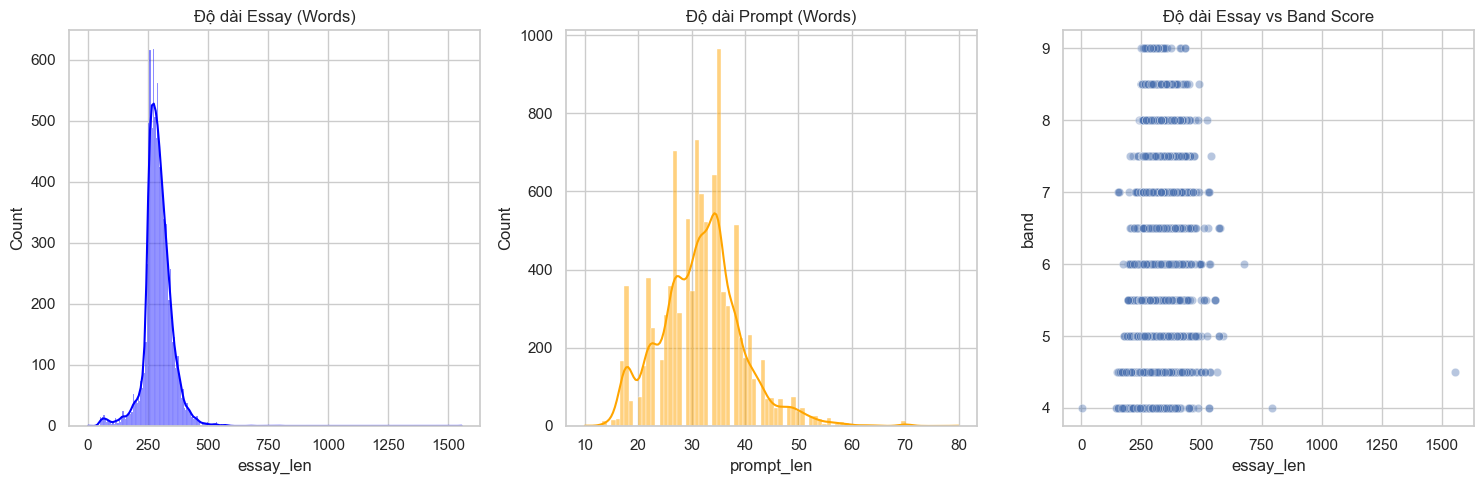

In [13]:
# Tính số từ (word count) cho các cột văn bản
df['essay_len'] = df['essay'].apply(lambda x: len(str(x).split()))
df['prompt_len'] = df['prompt'].apply(lambda x: len(str(x).split()))
df['eval_len'] = df['evaluation'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(15, 5))

# Biểu đồ phân phối độ dài Essay
plt.subplot(1, 3, 1)
sns.histplot(df['essay_len'], kde=True, color='blue')
plt.title('Độ dài Essay (Words)')

# Biểu đồ phân phối độ dài Prompt
plt.subplot(1, 3, 2)
sns.histplot(df['prompt_len'], kde=True, color='orange')
plt.title('Độ dài Prompt (Words)')

# Biểu đồ tương quan giữa Độ dài Essay và Điểm số
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='essay_len', y='band', alpha=0.4)
plt.title('Độ dài Essay vs Band Score')

plt.tight_layout()
plt.show()

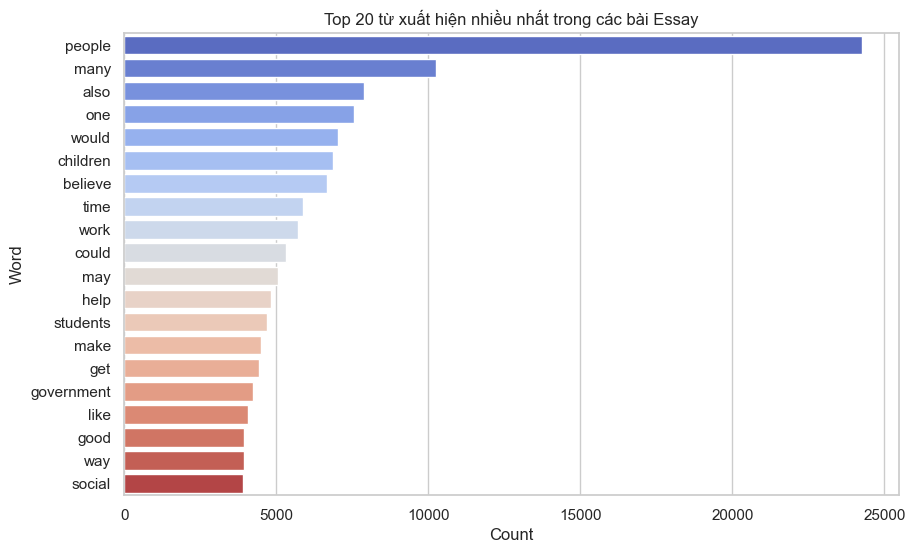

In [15]:
def get_top_n_words(corpus, n=20):
    words = []
    for text in corpus:
        tokens = str(text).lower().split()
        words.extend([w for w in tokens if w.isalpha() and w not in stop_words])
    return Counter(words).most_common(n)

top_words = get_top_n_words(df['essay'])
word_df = pd.DataFrame(top_words, columns=['Word', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=word_df, x='Count', y='Word', palette='coolwarm')
plt.title('Top 20 từ xuất hiện nhiều nhất trong các bài Essay')
plt.show()